In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\python\Visual Studio Code\Sales_Data.csv")

In [3]:
df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

In [5]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1.0,700.00,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1.0,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2.0,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1.0,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1.0,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


In [6]:
import pandas as pd

df["Quantity Ordered"] = pd.to_numeric(df["Quantity Ordered"])
df["Price Each"] = pd.to_numeric(df["Price Each"])

df["Revenue"] = df["Quantity Ordered"] * df["Price Each"]

print(df.head())

   Order ID                   Product  Quantity Ordered  Price Each  \
0    141234                    iPhone               1.0      700.00   
1    141235  Lightning Charging Cable               1.0       14.95   
2    141236          Wired Headphones               2.0       11.99   
3    141237          27in FHD Monitor               1.0      149.99   
4    141238          Wired Headphones               1.0       11.99   

       Order Date                       Purchase Address  Revenue  
0  01/22/19 21:25        944 Walnut St, Boston, MA 02215   700.00  
1  01/28/19 14:15       185 Maple St, Portland, OR 97035    14.95  
2  01/17/19 13:33  538 Adams St, San Francisco, CA 94016    23.98  
3  01/05/19 20:33     738 10th St, Los Angeles, CA 90001   149.99  
4  01/25/19 11:59          387 10th St, Austin, TX 73301    11.99  


In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

C:\Users\Dell\AppData\Local\Temp\ipykernel_1276\13081262.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


In [9]:
df["monthly_sales"] = df["Month"] * df["Revenue"]


In [10]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Revenue,Month,monthly_sales
0,141234,iPhone,1.0,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",700.00,1,700.00
1,141235,Lightning Charging Cable,1.0,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",14.95,1,14.95
2,141236,Wired Headphones,2.0,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",23.98,1,23.98
3,141237,27in FHD Monitor,1.0,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",149.99,1,149.99
4,141238,Wired Headphones,1.0,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",11.99,1,11.99


In [11]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

print(monthly_sales)

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Revenue, dtype: float64


In [12]:
top_products = df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)

print(top_products)

Product
AAA Batteries (4-pack)        31017.0
AA Batteries (4-pack)         27635.0
USB-C Charging Cable          23975.0
Lightning Charging Cable      23217.0
Wired Headphones              20557.0
Apple Airpods Headphones      15661.0
Bose SoundSport Headphones    13457.0
27in FHD Monitor               7550.0
iPhone                         6849.0
27in 4K Gaming Monitor         6244.0
34in Ultrawide Monitor         6199.0
Google Phone                   5532.0
Flatscreen TV                  4819.0
Macbook Pro Laptop             4728.0
ThinkPad Laptop                4130.0
20in Monitor                   4129.0
Vareebadd Phone                2068.0
LG Washing Machine              666.0
LG Dryer                        646.0
Name: Quantity Ordered, dtype: float64


In [13]:
df["City"] = df["Purchase Address"].apply(lambda x: x.split(",")[1])

In [14]:
city_sales = df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

print(city_sales)

City
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Revenue, dtype: float64


In [15]:
df.to_csv("cleaned_sales_data.csv", index=False)

<Axes: title={'center': 'Monthly Sales Analysis'}, xlabel='Month', ylabel='Revenue'>

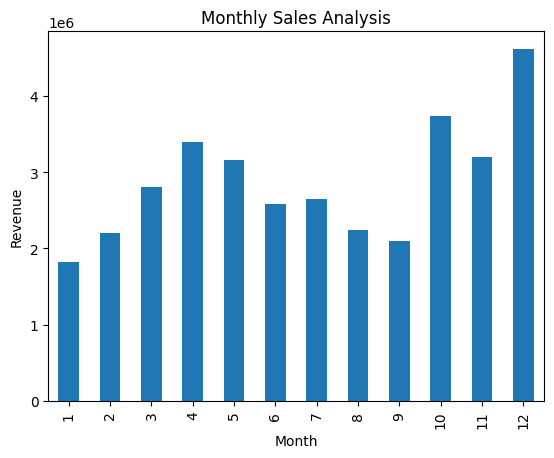

In [16]:
monthly_sales.plot(kind="bar", title="Monthly Sales Analysis", xlabel="Month", ylabel="Revenue")

In [17]:
top_products = df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)

<Axes: title={'center': 'Top Selling Products'}, xlabel='Product', ylabel='Quantity Sold'>

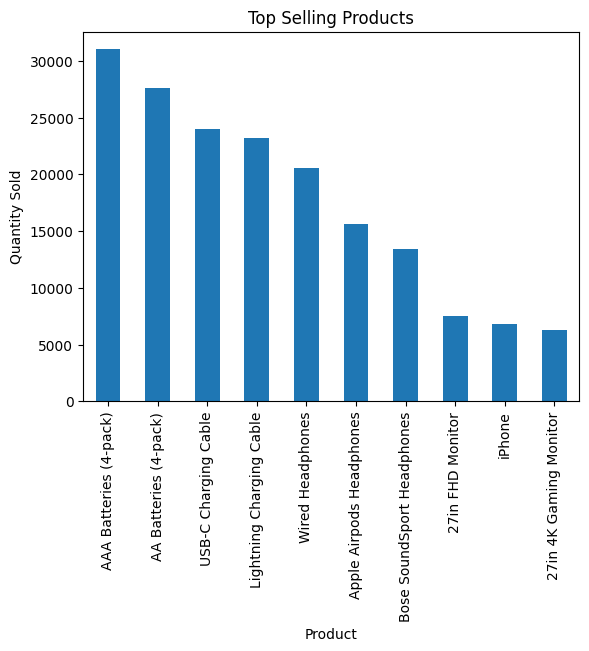

In [18]:
top_products.head(10).plot(kind="bar", title="Top Selling Products", xlabel="Product", ylabel="Quantity Sold")

<Axes: title={'center': 'Sales by City'}, xlabel='City', ylabel='Revenue'>

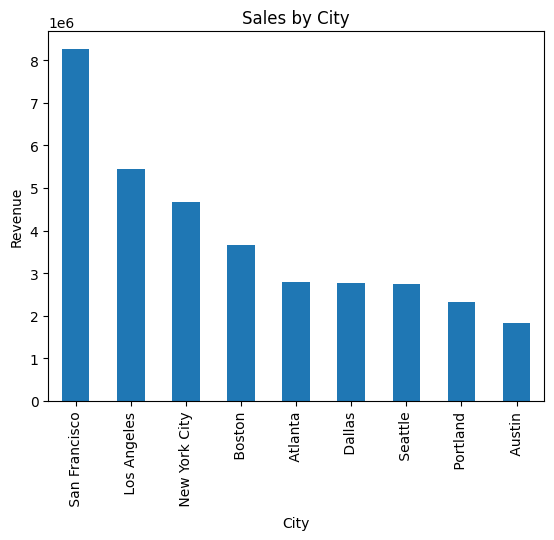

In [23]:
city_sales.plot(kind="bar", title="Sales by City", xlabel="City", ylabel="Revenue")